In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
from  pathlib import Path
from tqdm import tqdm

### Downloading the data

In [5]:
# Set the path to the file you'd like to load

path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")
print("Path to dataset files:", path)

Path to dataset files: /Users/hanane/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3


In [6]:
dataset_dir = Path("/Users/hanane/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3")
csv_path = next(dataset_dir.glob("*.csv"))

In [7]:
df = pd.read_csv(csv_path)
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


## Part 1 : Understanding Product Categories

- What are the most popular product categories on Amazon UK, and How do they compare in terms of listing frequency

In [8]:
# Frequency table
frequency_table = df['category'].value_counts()
proportion_table = df['category'].value_counts(normalize=True)
frequency_table, proportion_table


(category
 Sports & Outdoors                         836265
 Beauty                                     19312
 Handmade Clothing, Shoes & Accessories     19229
 Bath & Body                                19092
 Birthday Gifts                             18978
                                            ...  
 Alexa Built-In Devices                       107
 Motorbike Chassis                            107
 Plugs                                        107
 Smart Home Security & Lighting               104
 Smart Speakers                                54
 Name: count, Length: 296, dtype: int64,
 category
 Sports & Outdoors                         0.342219
 Beauty                                    0.007903
 Handmade Clothing, Shoes & Accessories    0.007869
 Bath & Body                               0.007813
 Birthday Gifts                            0.007766
                                             ...   
 Alexa Built-In Devices                    0.000044
 Motorbike Chassis       

/var/folders/9l/kk5xty3s5gn6t443byvnr8040000gn/T/ipykernel_31229/558317400.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frequency_table.head(5).index, y=frequency_table.head(5).values, palette="Set3")


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Sports & Outdoors'),
  Text(1, 0, 'Beauty'),
  Text(2, 0, 'Handmade Clothing, Shoes & Accessories'),
  Text(3, 0, 'Bath & Body'),
  Text(4, 0, 'Birthday Gifts')])

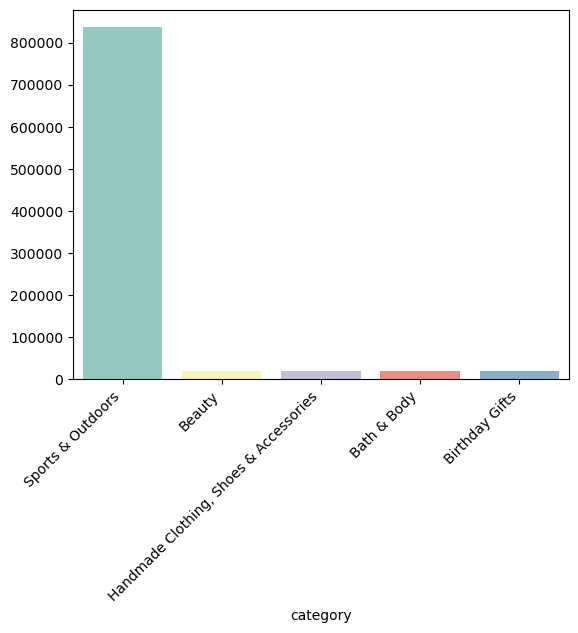

In [9]:
sns.barplot(x=frequency_table.head(5).index, y=frequency_table.head(5).values, palette="Set3")
plt.xticks(rotation=45, ha="right")

## Part 2 : Delving into Product pricing

In [17]:
mean = df['price'].mean().round(2)
median = df['price'].median()
mode = df['price'].mode()
print(f"Mean: {mean}, Median: {median}, Mode: {mode}")

Mean: 89.24, Median: 19.09, Mode: 0    9.99
Name: price, dtype: float64


In [20]:
variance = df['price'].var()
std_dev = df['price'].std()
min_price = df['price'].min()
max_price = df['price'].max()

In [21]:
range_price = max_price - min_price

In [22]:
quantiles = df['price'].quantile([0.25, 0.5, 0.75])
iqr = df['price'].quantile(0.75) - df['price'].quantile(0.25)


In [23]:
variance, std_dev, min_price, max_price, range_price, quantiles, iqr

(119445.4853225653,
 345.6088617535223,
 0.0,
 100000.0,
 100000.0,
 0.25     9.99
 0.50    19.09
 0.75    45.99
 Name: price, dtype: float64,
 np.float64(36.0))

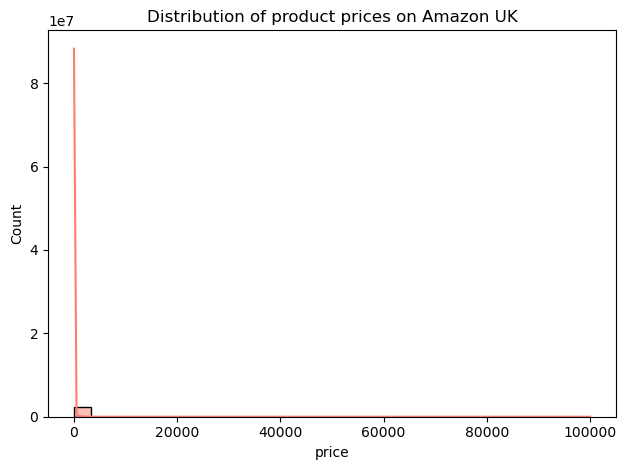

In [24]:
sns.histplot(df['price'], kde=True, bins=30, color="salmon")
plt.title("Distribution of product prices on Amazon UK")
plt.tight_layout()
plt.show()

A small number of very expensive products (outliers) stretch the x-axis way out
there's a long tail on the right side... the KDE also shows the right-skewed nature

In [25]:
df_filtered = df[df['price'] < 500]

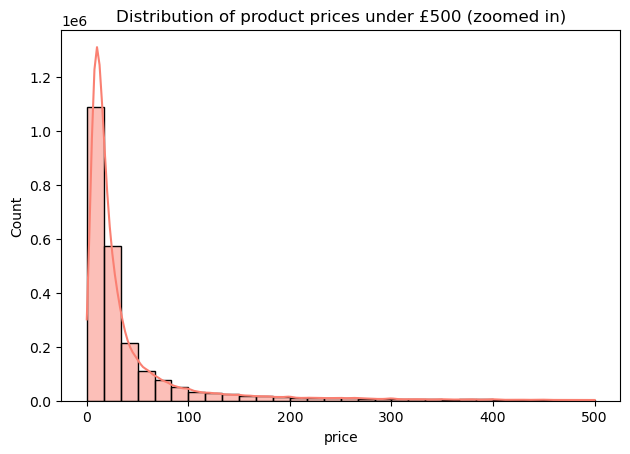

In [27]:
sns.histplot(df_filtered['price'], kde=True, bins=30, color="salmon")
plt.title("Distribution of product prices under £500 (zoomed in)")
plt.tight_layout()
plt.show()

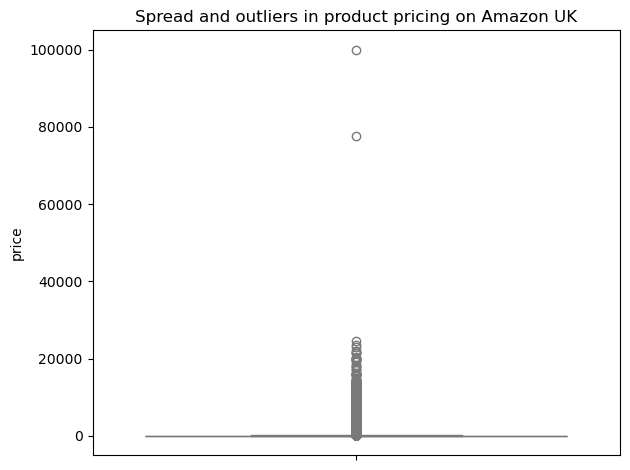

In [29]:
sns.boxplot(data=df['price'], color="lightblue")
plt.title("Spread and outliers in product pricing on Amazon UK")
plt.tight_layout()
plt.show()

## Part 3 : Unpacking Product ratings

In [31]:
mean_rating = df['stars'].mean().round(2)
median_rating = df['stars'].median()
mode_rating = df['stars'].mode()[0]
 
mean_rating, median_rating, mode_rating

(np.float64(2.15), 0.0, np.float64(0.0))

In [35]:
variance_rating = df['stars'].var()
std_dev_rating = df['stars'].std()
quantiles_rating = df['stars'].quantile([0.25, 0.5, 0.75])
iqr_rating = df['stars'].quantile(0.75) - df['stars'].quantile(0.25)
 
variance_rating, std_dev_rating, quantiles_rating, iqr_rating

(4.81743402976196,
 2.1948653785054697,
 0.25    0.0
 0.50    0.0
 0.75    4.4
 Name: stars, dtype: float64,
 np.float64(4.4))

In [38]:
skewness_rating = df['stars'].skew()
skewness_rating

np.float64(0.08120735761080881)

In [39]:
kurtosis_rating = df['stars'].kurtosis()
kurtosis_rating

np.float64(-1.9260061280432994)

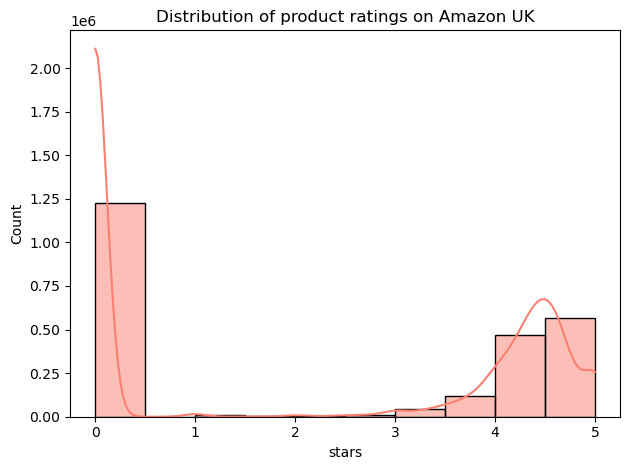

In [40]:
sns.histplot(df['stars'], kde=True, bins=10, color="salmon")
plt.title("Distribution of product ratings on Amazon UK")
 
plt.tight_layout()
plt.show()